In [12]:
import pandas as pd
data = {
    "gelir": [32000, 45000, 58000, 62000, 29000, 70000, 52000, 81000, 47000, 90000,
              61000, 38000, 55000, 73000, 34000, 68000, 49000, 76000, 43000, 64000,
              57000, 36000, 85000, 51000],
    "yas": [22, 25, 27, 30, 21, 35, 28, 40, 26, 45,
            31, 24, 29, 38, 23, 34, 27, 39, 25, 33,
            30, 22, 42, 28],
    "mevcut_borc": [18000, 12000, 10000, 9000, 15000, 8000, 14000, 5000, 11000, 4000,
                    9500, 17000, 13000, 6000, 16000, 7000, 12500, 5500, 14500, 8500,
                    10000, 17500, 4500, 13500],
    "kredi_puani": [480, 520, 610, 640, 450, 700, 590, 760, 560, 790,
                    650, 500, 600, 720, 490, 690, 570, 740, 530, 660,
                    620, 470, 780, 585],
    "sonuc": [0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
              1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
              1, 0, 1, 0]
}

df = pd.DataFrame(data)
print(df)

    gelir  yas  mevcut_borc  kredi_puani  sonuc
0   32000   22        18000          480      0
1   45000   25        12000          520      0
2   58000   27        10000          610      1
3   62000   30         9000          640      1
4   29000   21        15000          450      0
5   70000   35         8000          700      1
6   52000   28        14000          590      0
7   81000   40         5000          760      1
8   47000   26        11000          560      0
9   90000   45         4000          790      1
10  61000   31         9500          650      1
11  38000   24        17000          500      0
12  55000   29        13000          600      1
13  73000   38         6000          720      1
14  34000   23        16000          490      0
15  68000   34         7000          690      1
16  49000   27        12500          570      0
17  76000   39         5500          740      1
18  43000   25        14500          530      0
19  64000   33         8500          660

In [14]:
Özellikler ve hedef değişkenin ayrılması

Makine öğrenmesinde önce girişler ve hedef ayrılır.

X → bağımsız değişkenler
y → hedef değişken

SyntaxError: invalid character '→' (U+2192) (752871736.py, line 5)

In [15]:
X = df[["gelir", "yas", "mevcut_borc", "kredi_puani"]]
y = df["sonuc"]

Eğitim ve test verisinin ayrılması

Bir modelin gerçekten öğrenip öğrenmediğini görmek için veri ikiye ayrılır:

eğitim verisi → modelin öğrendiği bölüm
test verisi → modelin hiç görmediği bölüm

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [17]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

Decision Tree ile sınıflandırma
Teorik mantık

Decision Tree, veriyi soru sorarak dallandırır.

Örneğin iç mantık şu tarz olabilir:

Kredi puanı 600’den büyük mü?
Evet → gelir yüksek mi?
Evet → onay
Hayır → duruma göre karar
Hayır → red

Yani insanın karar verme mantığına benzeyen bir yapı kurar.

Açıklama
DecisionTreeClassifier() karar ağacı modelini oluşturur
max_depth=3 ağacın çok büyümesini engeller
fit() modeli eğitir
predict() test verisi için tahmin üretir

Decision Tree başarım ölçümü:

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))
print("Classification Report:")
print(classification_report(y_test, dt_pred))

=== Decision Tree ===
Accuracy: 1.0
Confusion Matrix:
[[5 0]
 [0 1]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         1

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



Yeni müşteri için tahmin yapma


Yeni müşteri bilgileri şöyle olsun:

gelir = 60000
yaş = 32
mevcut borç = 8500
kredi puanı = 670
Decision Tree ile tahmin

In [19]:
yeni_musteri = [[60000, 32, 8500, 670]]
tahmin = dt_model.predict(yeni_musteri)

if tahmin[0] == 1:
    print("Başvuru ONAYLANIR")
else:
    print("Başvuru REDDEDİLİR")

Başvuru ONAYLANIR


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Görselleştirme ve Açıklama:
kredi_puani <= 605 → karar sorusu
gini → saflık ölçüsü (0’a yakınsa daha iyi)
samples → bu node’daki veri sayısı
value = [10, 8] →
10 RED
8 ONAY
class → modelin verdiği karar

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

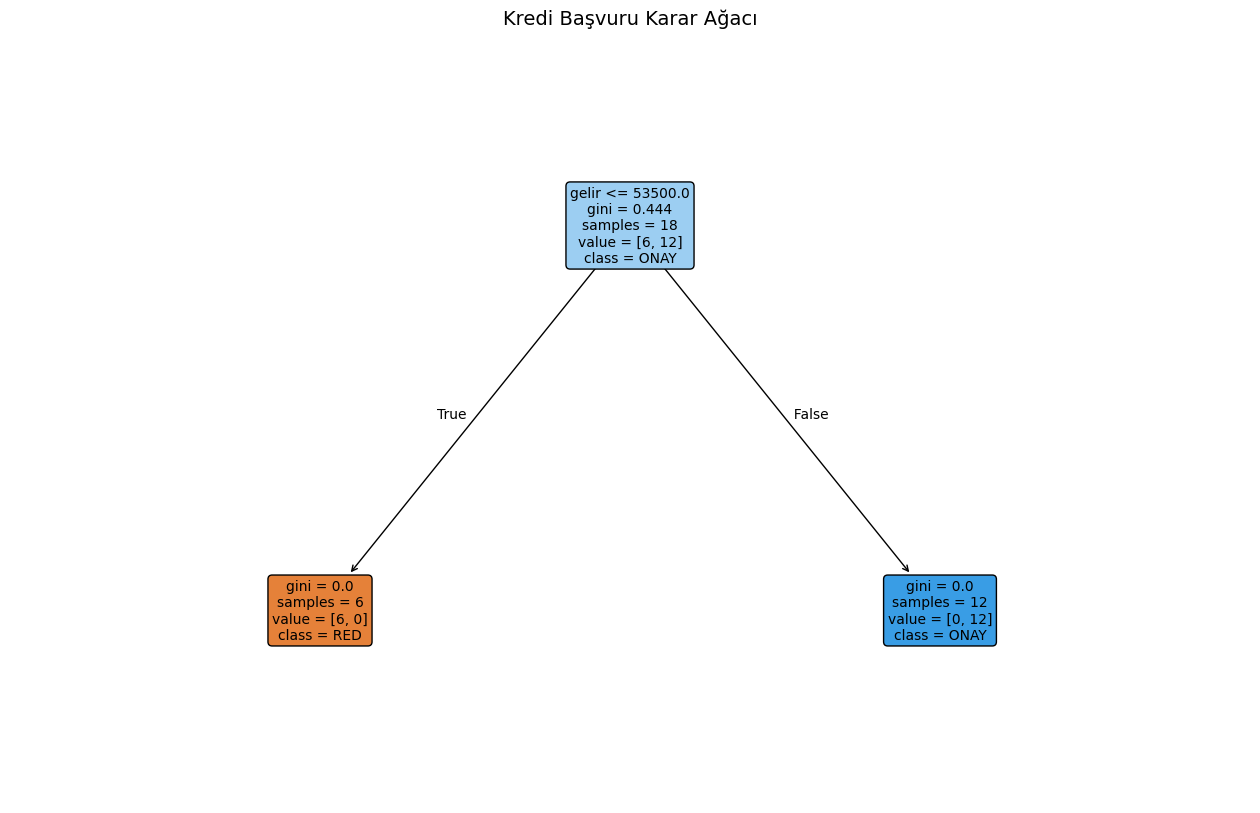

In [22]:
plt.figure(figsize=(16,10))

tree.plot_tree(
    dt_model,
    feature_names=["gelir", "yas", "mevcut_borc", "kredi_puani"],
    class_names=["RED", "ONAY"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Kredi Başvuru Karar Ağacı", fontsize=14)
plt.show()

Daha ayrıntılı için : Graphiz kütüphanesinin kullanımı


In [23]:
!pip install graphviz

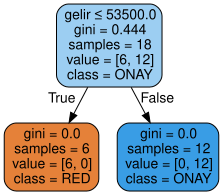

In [26]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dt_model,
    out_file=None,
    feature_names=["gelir", "yas", "mevcut_borc", "kredi_puani"],
    class_names=["RED", "ONAY"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph